In [10]:
# Loading Library
from stoneforge.data_management.preprocessing import DataLoader, DataManager
from stoneforge.petrophysics.shale_volume import vshale_linear
from stoneforge.pseudo_wells import color_codes
from stoneforge.vis.img import fastplot
import numpy as np

In [2]:
# Manual Access:

las2 = DataLoader(r"https://raw.githubusercontent.com/giecaruff/datasets/refs/heads/main/wells/las2/npra/IK1.las", filetype='las2')
print('header itens:',las2.data_obj.header.keys())
las2.data_obj.header['well']

header itens: dict_keys(['version', 'well', 'curve', 'parameter', 'other'])


,mnemonic,unit,value,description
0,STRT,F,81.0000,START DEPTH
1,STOP,F,15400.0000,STOP DEPTH
2,STEP,F,0.5000,STEP VALUE
3,NULL,,-999.2500,NULL VALUE
4,COMP,,USGS/NPR HUSKY OIL OPERAT,COMPANY
5,WELL,,IKPIKPUK TEST WELL #1,WELL
6,FLD,,WILDCAT,FIELD
7,LOC,,25 13N 10W,LOCATION
8,CNTY,,NORTH SLPOE,COUNTY
9,STAT,,ALASKA,STATE


In [3]:
# View Raw Data
print(las2.data_obj.data)

{'DEPT': {'values': array([   81. ,    81.5,    82. , ..., 15480. , 15480.5, 15481. ],
      shape=(30801,)), 'unit': 'F', 'description': '1  DEPTH'}, 'SP': {'values': array([-999., -999., -999., ..., -999., -999., -999.], shape=(30801,)), 'unit': 'MV', 'description': '2'}, 'ILD': {'values': array([-999., -999., -999., ..., -999., -999., -999.], shape=(30801,)), 'unit': 'OHMM', 'description': '3'}, 'ILM': {'values': array([-999., -999., -999., ..., -999., -999., -999.], shape=(30801,)), 'unit': 'OHMM', 'description': '4'}, 'LL8': {'values': array([-999., -999., -999., ..., -999., -999., -999.], shape=(30801,)), 'unit': 'OHMM', 'description': '5'}, 'GR': {'values': array([  79.7502,   79.979 ,   79.8643, ..., -999.    , -999.    ,
       -999.    ], shape=(30801,)), 'unit': 'GAPI', 'description': '6'}, 'CALI': {'values': array([-999., -999., -999., ..., -999., -999., -999.], shape=(30801,)), 'unit': 'IN', 'description': '7'}, 'RHOB': {'values': array([-999., -999., -999., ..., -999., -9

In [4]:
# Example (Manual Access): Accessing data as DataFrame
data_las2, units_las2 = las2.dataframe(las2.data_obj.data)
data_las2 = data_las2.replace(-999.0, np.nan)
data_las2

,DEPT,SP,ILD,ILM,LL8,GR,CALI,RHOB,DRHO,NPHI,DT
0,81.0,NaN,NaN,NaN,NaN,79.7502,NaN,NaN,NaN,NaN,NaN
1,81.5,NaN,NaN,NaN,NaN,79.9790,NaN,NaN,NaN,NaN,NaN
2,82.0,NaN,NaN,NaN,NaN,79.8643,NaN,NaN,NaN,NaN,NaN
3,82.5,NaN,NaN,NaN,NaN,79.9446,NaN,NaN,NaN,NaN,NaN
4,83.0,NaN,NaN,NaN,NaN,80.1459,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
30796,15479.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30797,15479.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30798,15480.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30799,15480.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


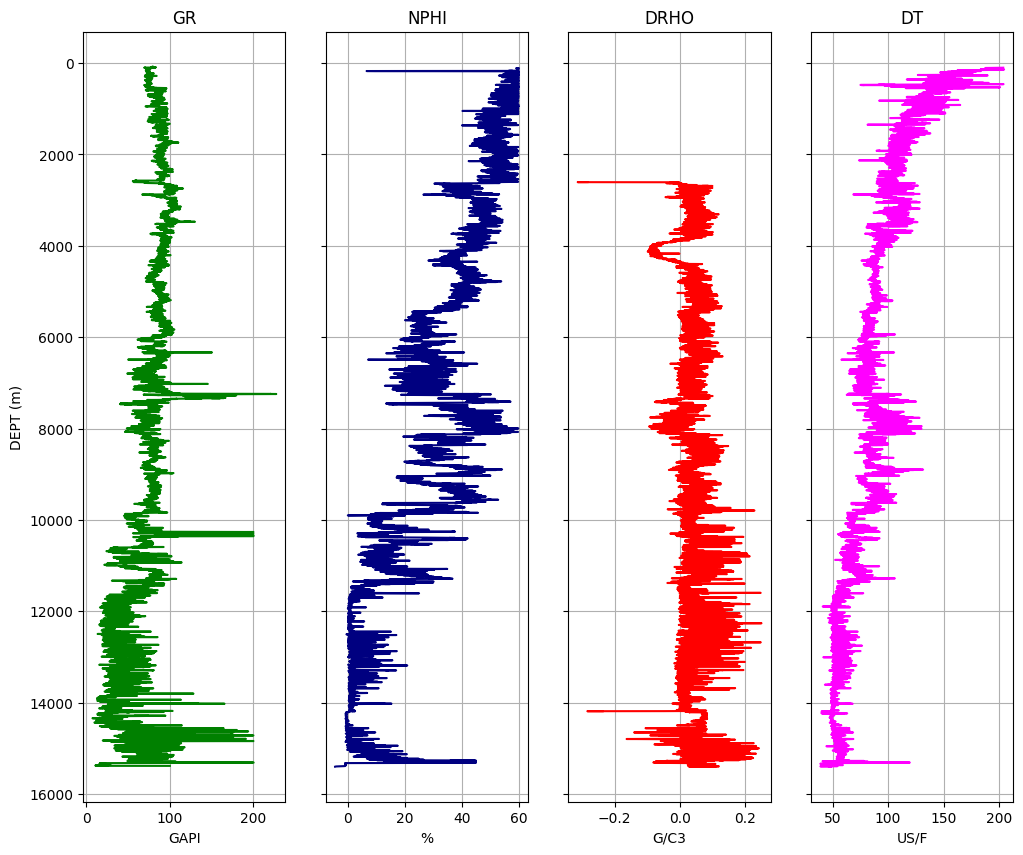

In [5]:
curves = ['GR', 'NPHI', 'DRHO', 'DT']
units2 = []
for c in curves:
    units2.append(units_las2[c])

color = ["green","navy","red","magenta"]

lito, fluid = color_codes()

pw = fastplot(data_las2, "DEPT", curves, color, units2)

In [6]:
IK1 = DataManager(las2, depth="DEPT")

formations = {
    'NANUSHUK':(2930,2961),
    'TOROK':(3784,7143),
    'LISBURNE':(11718,14986),
    'BASEMENT':(15000,16000),
    }

IK1.add_facie(name="LEDGE_SANDSTONE", top=10619, bottom=10842)

IK1.add_facies(formations)

In [7]:
IK1.NANUSHUK

,DEPT,SP,ILD,ILM,LL8,GR,CALI,RHOB,DRHO,NPHI,DT
5698,2930.0,-57.5401,9.2405,7.9118,8.0381,91.9616,14.5353,2.0845,-0.0316,41.6930,97.3888
5699,2930.5,-56.6911,9.2005,7.5635,7.6901,91.9621,14.5549,2.1110,-0.0320,40.9699,94.7699
5700,2931.0,-56.2212,9.1607,7.6087,7.8318,92.3008,14.5345,2.1098,-0.0298,40.6689,94.2469
5701,2931.5,-55.9798,9.0615,7.9288,8.1486,92.5656,14.5114,2.0928,-0.0280,40.8473,96.8504
5702,2932.0,-55.7499,8.9588,8.2623,8.4168,91.4390,14.4883,2.0981,-0.0260,42.0227,98.7639
...,...,...,...,...,...,...,...,...,...,...,...
5756,2959.0,-46.1916,8.3419,6.7388,6.9945,96.9943,14.6804,2.1443,0.0490,45.3106,113.9910
5757,2959.5,-46.3787,8.3055,6.8614,7.0950,96.5952,14.5599,2.1343,0.0490,46.6703,112.3054
5758,2960.0,-46.4893,8.2693,6.9591,8.1188,96.8863,14.2305,2.1243,0.0411,48.1521,109.6883
5759,2960.5,-46.5189,8.2332,6.6887,7.0604,97.2504,14.2005,2.1391,0.0502,49.0349,104.0030


In [8]:
IK1.LEDGE_SANDSTONE

,DEPT,SP,ILD,ILM,LL8,GR,CALI,RHOB,DRHO,NPHI,DT
21076,10619.0,-92.3719,5.6534,7.5047,10.3189,32.1681,9.5756,2.4324,0.0280,18.5964,74.0643
21077,10619.5,-92.6030,5.4512,7.1849,9.8774,29.9718,9.5682,2.4169,0.0243,18.5066,73.7811
21078,10620.0,-92.8108,5.2563,6.9832,9.3140,28.8898,9.5609,2.4278,0.0214,18.2585,73.3278
21079,10620.5,-93.0186,5.0684,6.7872,8.3432,28.8571,9.5536,2.4187,0.0232,18.0104,72.9256
21080,10621.0,-93.2263,4.9828,6.7115,7.1612,29.6683,9.5463,2.3921,0.0221,17.8458,73.9007
...,...,...,...,...,...,...,...,...,...,...,...
21518,10840.0,-84.3232,15.8031,24.9516,38.3127,38.1211,9.6802,2.5684,0.0246,9.2279,65.8097
21519,10840.5,-83.6495,18.1204,25.9377,29.7650,36.1407,9.6372,2.5561,0.0323,8.8146,63.3392
21520,10841.0,-82.9757,23.8513,37.9959,22.8938,36.0931,9.5941,2.5345,0.0364,8.6617,63.0884
21521,10841.5,-82.3019,24.9165,54.6157,25.3613,37.6945,9.5790,2.5176,0.0275,8.5357,63.5907


In [11]:
GR = np.array(IK1.LEDGE_SANDSTONE.GR)
GR_min = np.percentile(GR, 10)
GR_max = np.percentile(GR, 90)
print("GR_min:",GR_min,"|GR_max:",GR_max)

VSH = vshale_linear(gr=GR,grmin=GR_min,grmax=GR_max)

IK1.LEDGE_SANDSTONE.add_log("VSH", "", VSH)

GR_min: 30.78398 |GR_max: 88.65426000000001


In [12]:
IK1.NANUSHUK

,DEPT,SP,ILD,ILM,LL8,GR,CALI,RHOB,DRHO,NPHI,DT,VSH
5698,2930.0,-57.5401,9.2405,7.9118,8.0381,91.9616,14.5353,2.0845,-0.0316,41.6930,97.3888,NaN
5699,2930.5,-56.6911,9.2005,7.5635,7.6901,91.9621,14.5549,2.1110,-0.0320,40.9699,94.7699,NaN
5700,2931.0,-56.2212,9.1607,7.6087,7.8318,92.3008,14.5345,2.1098,-0.0298,40.6689,94.2469,NaN
5701,2931.5,-55.9798,9.0615,7.9288,8.1486,92.5656,14.5114,2.0928,-0.0280,40.8473,96.8504,NaN
5702,2932.0,-55.7499,8.9588,8.2623,8.4168,91.4390,14.4883,2.0981,-0.0260,42.0227,98.7639,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5756,2959.0,-46.1916,8.3419,6.7388,6.9945,96.9943,14.6804,2.1443,0.0490,45.3106,113.9910,NaN
5757,2959.5,-46.3787,8.3055,6.8614,7.0950,96.5952,14.5599,2.1343,0.0490,46.6703,112.3054,NaN
5758,2960.0,-46.4893,8.2693,6.9591,8.1188,96.8863,14.2305,2.1243,0.0411,48.1521,109.6883,NaN
5759,2960.5,-46.5189,8.2332,6.6887,7.0604,97.2504,14.2005,2.1391,0.0502,49.0349,104.0030,NaN


In [1]:
GR = np.array(IK1.NANUSHUK.GR)
GR_min = np.percentile(GR, 10)
GR_max = np.percentile(GR, 90)
print("GR_min:",GR_min,"|GR_max:",GR_max)

VSH = vshale_linear(gr=GR,grmin=GR_min,grmax=GR_max)

IK1.NANUSHUK.add_log("VSH", "", VSH)

NameError: name 'np' is not defined